In [4]:
!pip install earthengine-api geemap -q

In [2]:
#This is to publish comment
import ee
ee.Authenticate()
ee.Initialize(project='osmgee')

In [7]:
import ee
ee.Authenticate()
ee.Initialize(project='osmgee')

In [8]:
# --- Rema-Kalenga: boundary and site locations (SOURCE / TRAINING DATA) ---
rema_boundary = ee.FeatureCollection('projects/osmgee/assets/RemaKalenga')
rema_sites = ee.FeatureCollection('projects/osmgee/assets/RemaSites')

print('Rema-Kalenga boundary features:', rema_boundary.size().getInfo())
print('Rema-Kalenga sites features:', rema_sites.size().getInfo())

Rema-Kalenga boundary features: 1
Rema-Kalenga sites features: 59


In [13]:
# Print the property names (field names) of the first feature
rema_first_feature = rema_sites.first()
print('Available fields:', rema_first_feature.propertyNames().getInfo())

Available fields: ['XCoord', 'ClusterID', 'OBJECTID_1', 'FREQUENCY', 'MEAN_PAR_L', 'ClusterID_', 'MEAN_GAP_F', 'system:index', 'YCoord']


In [15]:
# Pull PAR LAI, coordinates, and cluster ID into a client-side list to inspect
rema_sites_info = rema_sites.select(['ClusterID', 'MEAN_PAR_L', 'XCoord', 'YCoord', 'longitude', 'Llllllatit']) \
                             .getInfo()

for f in rema_sites_info['features']:
    print(f['properties'])

{'ClusterID': 5, 'MEAN_PAR_L': 0.33117018625, 'XCoord': 91.62458, 'YCoord': 24.11235}
{'ClusterID': 27, 'MEAN_PAR_L': 3.94414734825, 'XCoord': 91.6306, 'YCoord': 24.165805}
{'ClusterID': 35, 'MEAN_PAR_L': 2.494383216, 'XCoord': 91.6436025, 'YCoord': 24.1705425}
{'ClusterID': 51, 'MEAN_PAR_L': 3.0017175675, 'XCoord': 91.6253075, 'YCoord': 24.2033275}
{'ClusterID': 3, 'MEAN_PAR_L': 2.8599865912, 'XCoord': 91.632832, 'YCoord': 24.109208}
{'ClusterID': 4, 'MEAN_PAR_L': 2.0680925488, 'XCoord': 91.626706, 'YCoord': 24.110476}
{'ClusterID': 7, 'MEAN_PAR_L': 3.1344433786, 'XCoord': 91.629136, 'YCoord': 24.113164}
{'ClusterID': 8, 'MEAN_PAR_L': 2.1191831826, 'XCoord': 91.630112, 'YCoord': 24.114924}
{'ClusterID': 9, 'MEAN_PAR_L': 3.2432822702, 'XCoord': 91.631906, 'YCoord': 24.116332}
{'ClusterID': 10, 'MEAN_PAR_L': 4.013032341, 'XCoord': 91.635002, 'YCoord': 24.11571}
{'ClusterID': 11, 'MEAN_PAR_L': 4.2924194338, 'XCoord': 91.635178, 'YCoord': 24.116774}
{'ClusterID': 12, 'MEAN_PAR_L': 2.62815

In [11]:
# Rebuild a clean FeatureCollection with unambiguous field names
def clean_feature_rema(f):
    lon = ee.Number(f.get('XCoord'))   # confirmed: longitude
    lat = ee.Number(f.get('YCoord'))   # confirmed: latitude
    par_lai = ee.Number(f.get('MEAN_PAR_L'))
    cluster_id = f.get('ClusterID')
    
    return ee.Feature(
        ee.Geometry.Point([lon, lat]),
        {
            'cluster_id': cluster_id,
            'par_lai': par_lai,
            'longitude': lon,
            'latitude': lat
        }
    )

rema_sites_clean = rema_sites.map(clean_feature_rema)

print('Cleaned feature count:', rema_sites_clean.size().getInfo())
print('Sample feature:', rema_sites_clean.first().getInfo())

Cleaned feature count: 59
Sample feature: {'type': 'Feature', 'geometry': {'type': 'Point', 'coordinates': [91.62458, 24.11235]}, 'id': '00000000000000000004', 'properties': {'cluster_id': 5, 'latitude': 24.11235, 'longitude': 91.62458, 'par_lai': 0.33117018625}}


In [16]:
# Define field campaign search window for Rema-Kalenga
rema_field_start = ee.Date('2021-01-01')
rema_field_end = ee.Date('2021-03-31')

# Load Sentinel-2 SR, filtered to Rema-Kalenga boundary and date window
rema_s2_collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(rema_boundary) \
    .filterDate(rema_field_start, rema_field_end) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30))

print('Number of available Sentinel-2 scenes (Rema-Kalenga):', rema_s2_collection.size().getInfo())

rema_image_list = rema_s2_collection.toList(rema_s2_collection.size())
n_rema = rema_s2_collection.size().getInfo()
for i in range(n_rema):
    img = ee.Image(rema_image_list.get(i))
    date = img.date().format('YYYY-MM-dd').getInfo()
    cloud = img.get('CLOUDY_PIXEL_PERCENTAGE').getInfo()
    print(f'{date}  —  cloud cover: {cloud:.1f}%')

Number of available Sentinel-2 scenes (Rema-Kalenga): 15
2021-01-01  —  cloud cover: 0.0%
2021-01-06  —  cloud cover: 0.0%
2021-01-16  —  cloud cover: 0.1%
2021-01-26  —  cloud cover: 3.9%
2021-01-31  —  cloud cover: 0.0%
2021-01-31  —  cloud cover: 0.0%
2021-02-05  —  cloud cover: 0.0%
2021-02-10  —  cloud cover: 0.0%
2021-02-15  —  cloud cover: 0.0%
2021-02-25  —  cloud cover: 17.2%
2021-03-02  —  cloud cover: 0.0%
2021-03-12  —  cloud cover: 0.1%
2021-03-17  —  cloud cover: 0.4%
2021-03-22  —  cloud cover: 0.1%
2021-03-27  —  cloud cover: 0.2%


In [17]:
# Cloud masking function using the SCL band
def mask_s2_clouds(image):
    scl = image.select('SCL')
    mask = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6)).Or(scl.eq(7))
    return image.updateMask(mask).divide(10000).copyProperties(image, image.propertyNames())

# Apply cloud masking
rema_s2_masked = rema_s2_collection.map(mask_s2_clouds)

# Build the median composite, clipped to Rema-Kalenga boundary
rema_s2_composite = rema_s2_masked.median().clip(rema_boundary)

# Compute spectral indices and add them to the composite (keeping original bands too)
def add_indices(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    gndvi = image.normalizedDifference(['B8', 'B3']).rename('GNDVI')
    
    evi = image.expression(
        '2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))', {
            'NIR': image.select('B8'),
            'RED': image.select('B4'),
            'BLUE': image.select('B2')
        }).rename('EVI')
    
    savi = image.expression(
        '((NIR - RED) / (NIR + RED + 0.5)) * 1.5', {
            'NIR': image.select('B8'),
            'RED': image.select('B4')
        }).rename('SAVI')
    
    msavi = image.expression(
        '(2 * NIR + 1 - sqrt((2 * NIR + 1)**2 - 8 * (NIR - RED))) / 2', {
            'NIR': image.select('B8'),
            'RED': image.select('B4')
        }).rename('MSAVI')
    
    return image.addBands([ndvi, gndvi, evi, savi, msavi])

rema_s2_with_indices = add_indices(rema_s2_composite)

# Select raw bands + indices
raw_bands = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
index_bands = ['NDVI', 'EVI', 'SAVI', 'GNDVI', 'MSAVI']

# Final Rema-Kalenga composite image: raw bands + indices
final_image_rema = rema_s2_with_indices.select(raw_bands + index_bands)

print('Bands in Rema-Kalenga composite:', final_image_rema.bandNames().getInfo())

Bands in Rema-Kalenga composite: ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12', 'NDVI', 'EVI', 'SAVI', 'GNDVI', 'MSAVI']


In [18]:
# Function to create a 15m x 15m square buffer around each point
def make_square_plot(feature):
    point = feature.geometry()
    half_side = 7.5
    square = point.buffer(half_side, 1).bounds()
    return feature.setGeometry(square)

# Apply to all Rema-Kalenga plots
rema_sites_squares = rema_sites_clean.map(make_square_plot)

sample_geom = rema_sites_squares.first().geometry().getInfo()
print('Sample square plot geometry (Rema-Kalenga):', sample_geom)

Sample square plot geometry (Rema-Kalenga): {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[91.6245064407107, 24.112283907026445], [91.62465051076359, 24.112283907026445], [91.62465051076359, 24.112417491494657], [91.6245064407107, 24.112417491494657], [91.6245064407107, 24.112283907026445]]]}


In [20]:
# Reduce final_image_rema (15 bands) over each 15x15m square plot, taking the mean
rema_extracted = final_image_rema.reduceRegions(
    collection=rema_sites_squares,
    reducer=ee.Reducer.mean(),
    scale=10
)

rema_extracted_info = rema_extracted.getInfo()

for f in rema_extracted_info['features'][:5]:
    print(f['properties'])
    print('---')

{'B11': 0.1424313874126094, 'B12': 0.07605951846821639, 'B2': 0.03815986338753643, 'B3': 0.05632864605271182, 'B4': 0.05276878090578532, 'B5': 0.08955574836933387, 'B6': 0.16989056556445653, 'B7': 0.1979732388953197, 'B8': 0.21721595298262442, 'B8A': 0.22457821902341332, 'EVI': 0.3295240016478683, 'GNDVI': 0.5881837211007394, 'MSAVI': 0.2865358184444568, 'NDVI': 0.6093240450955764, 'SAVI': 0.32037186901020626, 'cluster_id': 5, 'latitude': 24.11235, 'longitude': 91.62458, 'par_lai': 0.33117018625}
---
{'B11': 0.13595642711756364, 'B12': 0.07419382416568121, 'B2': 0.03904888607676606, 'B3': 0.055418353732259965, 'B4': 0.04904271107595126, 'B5': 0.08608490824188214, 'B6': 0.16773842216355928, 'B7': 0.19924750844876107, 'B8': 0.2114234987652731, 'B8A': 0.2198056567901199, 'EVI': 0.33465016761115257, 'GNDVI': 0.5849084310063751, 'MSAVI': 0.2855056384817451, 'NDVI': 0.6235347469083706, 'SAVI': 0.3202006578088804, 'cluster_id': 27, 'latitude': 24.165805, 'longitude': 91.6306, 'par_lai': 3.944

In [21]:
import pandas as pd

# Convert extracted GEE features into a clean pandas DataFrame
rema_rows = [f['properties'] for f in rema_extracted_info['features']]
df_rema = pd.DataFrame(rema_rows)

id_cols = ['cluster_id', 'par_lai', 'longitude', 'latitude']
other_cols = [c for c in df_rema.columns if c not in id_cols]
df_rema = df_rema[id_cols + other_cols]

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
df_rema

,cluster_id,par_lai,longitude,latitude,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,EVI,GNDVI,MSAVI,NDVI,SAVI
0,5,0.331170,91.624580,24.112350,0.142431,0.076060,0.038160,0.056329,0.052769,0.089556,0.169891,0.197973,0.217216,0.224578,0.329524,0.588184,0.286536,0.609324,0.320372
1,27,3.944147,91.630600,24.165805,0.135956,0.074194,0.039049,0.055418,0.049043,0.086085,0.167738,0.199248,0.211423,0.219806,0.334650,0.584908,0.285506,0.623535,0.320201
2,35,2.494383,91.643603,24.170542,0.132900,0.062900,0.034079,0.053245,0.042256,0.083800,0.187600,0.217200,0.236031,0.241500,0.392635,0.631831,0.343403,0.696248,0.373438
3,51,3.001718,91.625308,24.203328,0.141376,0.068436,0.045108,0.061773,0.057101,0.094538,0.170199,0.194622,0.201960,0.213711,0.300095,0.531006,0.251252,0.558760,0.286011
4,3,2.859987,91.632832,24.109208,0.133116,0.067745,0.031370,0.051638,0.039897,0.077071,0.164909,0.193969,0.220625,0.221189,0.368735,0.620361,0.323280,0.693238,0.356231
5,4,2.068093,91.626706,24.110476,0.148203,0.080440,0.034296,0.055003,0.043630,0.088897,0.180690,0.207163,0.230051,0.235389,0.376897,0.614208,0.329475,0.680068,0.360656
6,7,3.134443,91.629136,24.113164,0.130188,0.063803,0.031162,0.051708,0.044645,0.087437,0.170949,0.204057,0.208000,0.226724,0.328757,0.601572,0.290158,0.646415,0.325443
7,8,2.119183,91.630112,24.114924,0.124400,0.057700,0.028650,0.050205,0.039200,0.079700,0.187600,0.213200,0.227003,0.235100,0.376415,0.637759,0.335942,0.705474,0.367657
8,9,3.243282,91.631906,24.116332,0.129149,0.063149,0.033115,0.052032,0.042974,0.082926,0.175470,0.215170,0.237336,0.238305,0.389424,0.639471,0.343496,0.692662,0.373193
9,10,4.013032,91.635002,24.115710,0.132565,0.062171,0.031575,0.048792,0.037998,0.083369,0.192167,0.227811,0.247637,0.250866,0.422723,0.670577,0.373621,0.733398,0.399795


In [22]:
from sklearn.model_selection import train_test_split
import numpy as np

# Define feature columns (10 raw bands + 5 indices) and target
feature_cols = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12',
                 'NDVI', 'EVI', 'SAVI', 'GNDVI', 'MSAVI']
target_col = 'par_lai'

X_rema = df_rema[feature_cols]
y_rema = df_rema[target_col]

# 80/20 split
X_train_rema, X_test_rema, y_train_rema, y_test_rema = train_test_split(
    X_rema, y_rema, test_size=0.2, random_state=42
)

print('Train PAR LAI range:', round(y_train_rema.min(), 2), '-', round(y_train_rema.max(), 2))
print('Test PAR LAI range:', round(y_test_rema.min(), 2), '-', round(y_test_rema.max(), 2))
print('Train PAR LAI mean:', round(y_train_rema.mean(), 2))
print('Test PAR LAI mean:', round(y_test_rema.mean(), 2))

Train PAR LAI range: 0.35 - 4.29
Test PAR LAI range: 0.33 - 3.62
Train PAR LAI mean: 2.17
Test PAR LAI mean: 2.17


In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.metrics import mean_squared_error
import itertools

# Define hyperparameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 0.5, 1.0]
}

keys = list(param_grid.keys())
combinations = list(itertools.product(*param_grid.values()))
print(f'Total hyperparameter combinations to test: {len(combinations)}')

loo = LeaveOneOut()
rema_results = []

for combo in combinations:
    params = dict(zip(keys, combo))
    rf = RandomForestRegressor(random_state=42, **params)
    
    scores = cross_val_score(rf, X_train_rema, y_train_rema, cv=loo, scoring='neg_mean_squared_error')
    mean_mse = -scores.mean()
    rmse = np.sqrt(mean_mse)
    
    rema_results.append({**params, 'loocv_rmse': rmse})

results_df_rema = pd.DataFrame(rema_results).sort_values('loocv_rmse').reset_index(drop=True)
print('Top 5 hyperparameter combinations by LOOCV RMSE (Rema-Kalenga):')
results_df_rema.head(5)

Total hyperparameter combinations to test: 108
Top 5 hyperparameter combinations by LOOCV RMSE (Rema-Kalenga):


,n_estimators,max_depth,min_samples_leaf,max_features,loocv_rmse
0,100,5.0,1,sqrt,0.764902
1,100,10.0,1,sqrt,0.767595
2,100,15.0,1,sqrt,0.768480
3,100,NaN,1,sqrt,0.768480
4,100,5.0,2,sqrt,0.771325


Best hyperparameters selected via LOOCV (Rema-Kalenga):
{'n_estimators': 100, 'max_depth': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt'}

=== Rema-Kalenga model performance summary ===
                           Set  N    R2  RMSE   MAE  rRMSE (%)  Bias (mean residual)
Rema-Kalenga Train (in-sample) 47 0.842 0.349 0.271       16.1                -0.002
  Rema-Kalenga Test (held-out) 12 0.262 0.769 0.559       35.5                -0.004

=== Feature importance (Rema-Kalenga model) ===
Feature  Importance
     B3    0.105654
   NDVI    0.094778
    B11    0.093296
  GNDVI    0.093197
     B4    0.091144
    B12    0.086072
  MSAVI    0.079821
   SAVI    0.064925
    EVI    0.061510
     B5    0.047889
     B2    0.044254
    B8A    0.039046
     B6    0.038457
     B8    0.035743
     B7    0.024214

=== Per-plot residuals (Rema-Kalenga test set) ===
 cluster_id  observed_par_lai  predicted_par_lai  residual
          5          0.331170              2.168     1.836
          4      

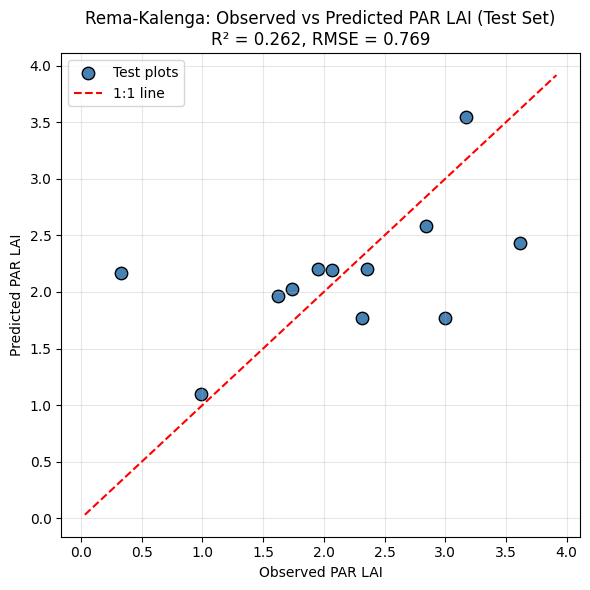

In [14]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Extract best hyperparameters from the LOOCV search
best_params_rema = results_df_rema.iloc[0][keys].to_dict()

best_params_rema['n_estimators'] = int(best_params_rema['n_estimators'])
best_params_rema['min_samples_leaf'] = int(best_params_rema['min_samples_leaf'])
best_params_rema['max_depth'] = None if pd.isna(best_params_rema['max_depth']) else int(best_params_rema['max_depth'])
if best_params_rema['max_features'] not in ['sqrt', 'log2']:
    best_params_rema['max_features'] = float(best_params_rema['max_features'])

print('Best hyperparameters selected via LOOCV (Rema-Kalenga):')
print(best_params_rema)
print()

# Refit final RF model on all Rema-Kalenga training plots — THIS IS THE MODEL USED FOR TRANSFER
final_rf_rema = RandomForestRegressor(random_state=42, **best_params_rema)
final_rf_rema.fit(X_train_rema, y_train_rema)

# --- Predictions on both train and test sets ---
y_pred_train_rema = final_rf_rema.predict(X_train_rema)
y_pred_test_rema = final_rf_rema.predict(X_test_rema)

def compute_metrics(y_true, y_pred, label):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    rrmse = (rmse / y_true.mean()) * 100
    bias = (y_pred - y_true).mean()
    return {
        'Set': label,
        'N': len(y_true),
        'R2': round(r2, 3),
        'RMSE': round(rmse, 3),
        'MAE': round(mae, 3),
        'rRMSE (%)': round(rrmse, 1),
        'Bias (mean residual)': round(bias, 3)
    }

metrics_train_rema = compute_metrics(y_train_rema, y_pred_train_rema, 'Rema-Kalenga Train (in-sample)')
metrics_test_rema = compute_metrics(y_test_rema, y_pred_test_rema, 'Rema-Kalenga Test (held-out)')

metrics_df_rema = pd.DataFrame([metrics_train_rema, metrics_test_rema])
print('=== Rema-Kalenga model performance summary ===')
print(metrics_df_rema.to_string(index=False))
print()

# --- Feature importance ---
importance_df_rema = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': final_rf_rema.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('=== Feature importance (Rema-Kalenga model) ===')
print(importance_df_rema.to_string(index=False))
print()

# --- Residuals table for the test set ---
residuals_df_rema = pd.DataFrame({
    'cluster_id': df_rema.loc[X_test_rema.index, 'cluster_id'].values,
    'observed_par_lai': y_test_rema.values,
    'predicted_par_lai': y_pred_test_rema.round(3),
    'residual': (y_pred_test_rema - y_test_rema.values).round(3)
})
print('=== Per-plot residuals (Rema-Kalenga test set) ===')
print(residuals_df_rema.to_string(index=False))
print()

# --- Scatter plot: observed vs predicted (test set) ---
plt.figure(figsize=(6, 6))
plt.scatter(y_test_rema, y_pred_test_rema, color='steelblue', edgecolor='black', s=80, label='Test plots')
lims = [min(y_test_rema.min(), y_pred_test_rema.min()) - 0.3, max(y_test_rema.max(), y_pred_test_rema.max()) + 0.3]
plt.plot(lims, lims, 'r--', label='1:1 line')
plt.xlabel('Observed PAR LAI')
plt.ylabel('Predicted PAR LAI')
plt.title(f'Rema-Kalenga: Observed vs Predicted PAR LAI (Test Set)\nR² = {metrics_test_rema["R2"]}, RMSE = {metrics_test_rema["RMSE"]}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Naive Spatial Transfer

In [15]:
# --- KNP: boundary and site locations (TRANSFER TARGET, not source/training data) ---
knp_boundary = ee.FeatureCollection('projects/osmgee/assets/KNP')
knp_sites = ee.FeatureCollection('projects/osmgee/assets/SitesLocation')

print('KNP boundary features:', knp_boundary.size().getInfo())
print('KNP sites features:', knp_sites.size().getInfo())

KNP boundary features: 1
KNP sites features: 40


In [16]:
# Rebuild the clean, unambiguous-field-name version
# (XCoord/Llllllatit = longitude, YCoord/longitude = latitude)
def clean_feature_knp(f):
    lon = ee.Number(f.get('XCoord'))
    lat = ee.Number(f.get('YCoord'))
    par_lai = ee.Number(f.get('MEAN_PAR_L'))
    cluster_id = f.get('ClusterID')
    
    return ee.Feature(
        ee.Geometry.Point([lon, lat]),
        {
            'cluster_id': cluster_id,
            'par_lai': par_lai,
            'longitude': lon,
            'latitude': lat
        }
    )

knp_sites_clean = knp_sites.map(clean_feature_knp)

print('Cleaned feature count:', knp_sites_clean.size().getInfo())
print('Sample feature:', knp_sites_clean.first().getInfo())

Cleaned feature count: 40
Sample feature: {'type': 'Feature', 'geometry': {'type': 'Point', 'coordinates': [91.94278, 24.95203]}, 'id': '0000000000000000000c', 'properties': {'cluster_id': '20', 'latitude': 24.95203, 'longitude': 91.94278, 'par_lai': 1.6706171335}}


In [17]:
# Rebuild the 15m x 15m square plots around each KNP point
def make_square_plot(feature):
    point = feature.geometry()
    half_side = 7.5
    square = point.buffer(half_side, 1).bounds()
    return feature.setGeometry(square)

knp_sites_squares = knp_sites_clean.map(make_square_plot)

print('Sample square geometry (KNP):', knp_sites_squares.first().geometry().getInfo())

Sample square geometry (KNP): {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[91.94270594703491, 24.951963907026418], [91.94285098397934, 24.951963907026418], [91.94285098397934, 24.952097491494666], [91.94270594703491, 24.952097491494666], [91.94270594703491, 24.951963907026418]]]}


In [18]:
# Define the date window for KNP model application
knp_apply_start = ee.Date('2022-01-01')
knp_apply_end = ee.Date('2022-03-31')

# Load Sentinel-2 SR, filtered to KNP boundary and this date window
knp_s2_collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(knp_boundary) \
    .filterDate(knp_apply_start, knp_apply_end) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30))

print('Number of available Sentinel-2 scenes (Jan-Mar 2021, KNP):', knp_s2_collection.size().getInfo())

knp_image_list = knp_s2_collection.toList(knp_s2_collection.size())
n_knp = knp_s2_collection.size().getInfo()
for i in range(n_knp):
    img = ee.Image(knp_image_list.get(i))
    date = img.date().format('YYYY-MM-dd').getInfo()
    cloud = img.get('CLOUDY_PIXEL_PERCENTAGE').getInfo()
    print(f'{date}  —  cloud cover: {cloud:.1f}%')

Number of available Sentinel-2 scenes (Jan-Mar 2021, KNP): 11
2022-01-01  —  cloud cover: 10.0%
2022-01-06  —  cloud cover: 19.3%
2022-01-26  —  cloud cover: 19.8%
2022-01-31  —  cloud cover: 1.5%
2022-02-15  —  cloud cover: 0.0%
2022-02-20  —  cloud cover: 3.5%
2022-03-02  —  cloud cover: 0.0%
2022-03-07  —  cloud cover: 0.0%
2022-03-12  —  cloud cover: 23.7%
2022-03-17  —  cloud cover: 0.0%
2022-03-22  —  cloud cover: 0.0%


In [19]:
# Cloud masking function (same as before)
def mask_s2_clouds(image):
    scl = image.select('SCL')
    mask = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6)).Or(scl.eq(7))
    return image.updateMask(mask).divide(10000).copyProperties(image, image.propertyNames())

# Apply cloud masking
knp_s2_masked = knp_s2_collection.map(mask_s2_clouds)

# Build the median composite, clipped to KNP boundary
# (fixed: was "knpp_boundary" — typo in your original)
knp_s2_composite = knp_s2_masked.median().clip(knp_boundary)

# Compute the same 5 indices as before
def add_indices(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    gndvi = image.normalizedDifference(['B8', 'B3']).rename('GNDVI')
    
    evi = image.expression(
        '2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))', {
            'NIR': image.select('B8'),
            'RED': image.select('B4'),
            'BLUE': image.select('B2')
        }).rename('EVI')
    
    savi = image.expression(
        '((NIR - RED) / (NIR + RED + 0.5)) * 1.5', {
            'NIR': image.select('B8'),
            'RED': image.select('B4')
        }).rename('SAVI')
    
    msavi = image.expression(
        '(2 * NIR + 1 - sqrt((2 * NIR + 1)**2 - 8 * (NIR - RED))) / 2', {
            'NIR': image.select('B8'),
            'RED': image.select('B4')
        }).rename('MSAVI')
    
    return image.addBands([ndvi, gndvi, evi, savi, msavi])

knp_s2_with_indices = add_indices(knp_s2_composite)

raw_bands = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
index_bands = ['NDVI', 'EVI', 'SAVI', 'GNDVI', 'MSAVI']

# Final KNP composite image
final_image_knp = knp_s2_with_indices.select(raw_bands + index_bands)

print('Bands in KNP composite:', final_image_knp.bandNames().getInfo())

Bands in KNP composite: ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12', 'NDVI', 'EVI', 'SAVI', 'GNDVI', 'MSAVI']


In [20]:
# Extract mean values over each 15x15m square at KNP
knp_extracted = final_image_knp.reduceRegions(
    collection=knp_sites_squares,
    reducer=ee.Reducer.mean(),
    scale=10
)

knp_extracted_info = knp_extracted.getInfo()

knp_rows = [f['properties'] for f in knp_extracted_info['features']]
df_knp = pd.DataFrame(knp_rows)

id_cols = ['cluster_id', 'par_lai', 'longitude', 'latitude']
other_cols = [c for c in df_knp.columns if c not in id_cols]
df_knp = df_knp[id_cols + other_cols]

print(f'Extracted {len(df_knp)} plots')
df_knp

Extracted 40 plots


,cluster_id,par_lai,longitude,latitude,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,EVI,GNDVI,MSAVI,NDVI,SAVI
0,20,1.670617,91.942780,24.952030,0.148272,0.071148,0.030400,0.046465,0.033724,0.083295,0.210989,0.256052,0.269581,0.288476,0.473796,0.706005,0.422154,0.777459,0.440098
1,2,3.038662,91.937182,24.952476,0.121299,0.054796,0.028936,0.048881,0.042311,0.073137,0.164237,0.199635,0.239743,0.225284,0.383648,0.657121,0.346851,0.698811,0.375263
2,27,2.154577,91.943748,24.945720,0.196215,0.114333,0.034056,0.054561,0.045360,0.107156,0.201953,0.242526,0.273257,0.267208,0.441903,0.667430,0.396632,0.716456,0.417396
3,40,0.285474,91.961718,24.971386,0.196767,0.120137,0.034067,0.051791,0.043418,0.099073,0.194840,0.228898,0.228201,0.254464,0.374257,0.629236,0.327087,0.679469,0.358600
4,11,3.923973,91.938690,24.952073,0.120839,0.056409,0.026086,0.043782,0.031075,0.073244,0.176348,0.213370,0.225074,0.234936,0.398095,0.672083,0.353558,0.755377,0.383709
5,13,3.148044,91.938552,24.954740,0.129963,0.066591,0.034634,0.051700,0.044072,0.079737,0.187206,0.230333,0.234959,0.256375,0.384945,0.637622,0.337546,0.683013,0.367012
6,25,4.923975,91.941830,24.948150,0.116373,0.056025,0.029673,0.041950,0.031873,0.067451,0.156370,0.195738,0.199374,0.201425,0.357448,0.652040,0.306207,0.722405,0.342229
7,32,1.538075,91.958823,24.968853,0.121981,0.059360,0.030057,0.042175,0.032960,0.065891,0.150383,0.184477,0.197692,0.206078,0.351879,0.648200,0.301041,0.713990,0.338077
8,33,3.215866,91.959881,24.966343,0.116688,0.054801,0.022995,0.034053,0.025020,0.061984,0.170161,0.207791,0.211276,0.234723,0.391125,0.721592,0.345815,0.787384,0.378820
9,36,3.479967,91.960536,24.968643,0.127217,0.063176,0.027015,0.041600,0.029176,0.068809,0.166674,0.204009,0.210436,0.224908,0.381259,0.666555,0.332292,0.752735,0.364988


=== Spatial Transfer Performance (Rema-Kalenga → KNP) ===
                                                   Set  N    R2  RMSE   MAE  rRMSE (%)  Bias (mean residual)
Spatial Transfer: Rema-Kalenga model -> KNP (40 plots) 40 0.088 1.154 0.984       47.2                  0.64

=== Per-plot residuals (KNP, spatial transfer) ===
cluster_id  observed_par_lai  predicted_par_lai  residual
        20             1.671              3.577     1.906
         2             3.039              3.398     0.359
        27             2.155              2.794     0.639
        40             0.285              2.118     1.832
        11             3.924              3.864    -0.060
        13             3.148              2.520    -0.628
        25             4.924              3.075    -1.849
        32             1.538              2.827     1.289
        33             3.216              3.687     0.471
        36             3.480              3.360    -0.120
        38             2.537      

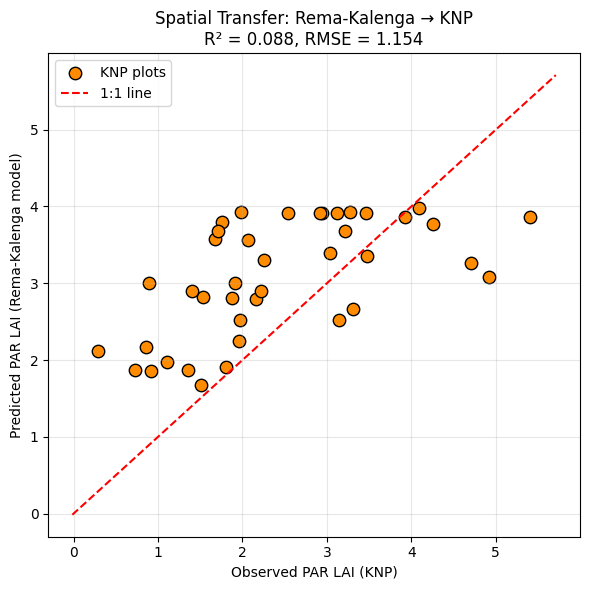

In [21]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Feature order must match what final_rf_rema was trained on
X_knp = df_knp[feature_cols]
y_knp_true = df_knp['par_lai']

# Apply the FROZEN Rema-Kalenga-trained model — no retraining
y_knp_pred = final_rf_rema.predict(X_knp)

def compute_metrics(y_true, y_pred, label):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    rrmse = (rmse / y_true.mean()) * 100
    bias = (y_pred - y_true).mean()
    return {
        'Set': label,
        'N': len(y_true),
        'R2': round(r2, 3),
        'RMSE': round(rmse, 3),
        'MAE': round(mae, 3),
        'rRMSE (%)': round(rrmse, 1),
        'Bias (mean residual)': round(bias, 3)
    }

metrics_transfer_knp = compute_metrics(y_knp_true, y_knp_pred, 'Spatial Transfer: Rema-Kalenga model -> KNP (40 plots)')
transfer_metrics_df_knp = pd.DataFrame([metrics_transfer_knp])

print('=== Spatial Transfer Performance (Rema-Kalenga → KNP) ===')
print(transfer_metrics_df_knp.to_string(index=False))
print()

transfer_residuals_df_knp = pd.DataFrame({
    'cluster_id': df_knp['cluster_id'],
    'observed_par_lai': y_knp_true.round(3),
    'predicted_par_lai': y_knp_pred.round(3),
    'residual': (y_knp_pred - y_knp_true).round(3)
})
print('=== Per-plot residuals (KNP, spatial transfer) ===')
print(transfer_residuals_df_knp.to_string(index=False))
print()

plt.figure(figsize=(6, 6))
plt.scatter(y_knp_true, y_knp_pred, color='darkorange', edgecolor='black', s=80, label='KNP plots')
lims = [min(y_knp_true.min(), y_knp_pred.min()) - 0.3, max(y_knp_true.max(), y_knp_pred.max()) + 0.3]
plt.plot(lims, lims, 'r--', label='1:1 line')
plt.xlabel('Observed PAR LAI (KNP)')
plt.ylabel('Predicted PAR LAI (Rema-Kalenga model)')
plt.title(f'Spatial Transfer: Rema-Kalenga → KNP\nR² = {metrics_transfer_knp["R2"]}, RMSE = {metrics_transfer_knp["RMSE"]}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# --- Export KNP composite ---
export_task_knp = ee.batch.Export.image.toDrive(
    image=final_image_knp,
    description='KNP_LAI_features_export',
    folder='GEE_exports',
    fileNamePrefix='KNP_features_2021_JanMar',
    region=knp_boundary.geometry(),
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)
export_task_knp.start()
print('KNP export task started. Task ID:', export_task_knp.id)

In [ ]:
# --- Export Rema-Kalenga composite ---
export_task_rema = ee.batch.Export.image.toDrive(
    image=final_image_rema,
    description='RemaKalenga_LAI_features_export',
    folder='GEE_exports',
    fileNamePrefix='RemaKalenga_features',
    region=rema_boundary.geometry(),
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)
export_task_rema.start()
print('Rema-Kalenga export task started. Task ID:', export_task_rema.id)

In [ ]:
# Check task status (run this cell repeatedly to monitor progress)
print('KNP task status:', export_task_knp.status()['state'])
print('Rema-Kalenga task status:', export_task_rema.status()['state'])